# Лабораторная № 6

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline


import seaborn as sns
import matplotlib.patches as mpatches
import time

import collections
from collections import Counter

import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Загрузка данных из Excel файла
df = pd.read_excel('Real estate valuation data set.xlsx')
df.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area,Возраст дома,Кол-во магазинов,Расстояние до ближайшей станции метро
0,1,2012.916667,32.0,84.87882,10,24.98298,121.54024,37.9,старый,много,далеко
1,2,2012.916667,19.5,306.59470,9,24.98034,121.53951,42.2,старый,много,далеко
2,3,2013.583333,13.3,561.98450,5,24.98746,121.54391,47.3,средний возраст,среднее,далеко
3,4,2013.500000,13.3,561.98450,5,24.98746,121.54391,54.8,средний возраст,среднее,далеко
4,5,2012.833333,5.0,390.56840,5,24.97937,121.54245,43.1,средний возраст,среднее,далеко


In [ ]:
df.describe()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
count,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000
mean,207.500000,2013.148953,17.712560,1083.885689,4.094203,24.969030,121.533361,37.980193
std,119.655756,0.281995,11.392485,1262.109595,2.945562,0.012410,0.015347,13.606488
min,1.000000,2012.666667,0.000000,23.382840,0.000000,24.932070,121.473530,7.600000
25%,104.250000,2012.916667,9.025000,289.324800,1.000000,24.963000,121.528085,27.700000
50%,207.500000,2013.166667,16.100000,492.231300,4.000000,24.971100,121.538630,38.450000
75%,310.750000,2013.416667,28.150000,1454.279000,6.000000,24.977455,121.543305,46.600000
max,414.000000,2013.583333,43.800000,6488.021000,10.000000,25.014590,121.566270,117.500000


In [ ]:
df.isnull().sum()

,0
No,0
X1 transaction date,0
X2 house age,0
X3 distance to the nearest MRT station,0
X4 number of convenience stores,0
X5 latitude,0
X6 longitude,0
Y house price of unit area,0
Возраст дома,0
Кол-во магазинов,0


In [ ]:
df.columns

Index(['No', 'X1 transaction date', 'X2 house age',
       'X3 distance to the nearest MRT station',
       'X4 number of convenience stores', 'X5 latitude', 'X6 longitude',
       'Y house price of unit area', 'Возраст дома', 'Кол-во магазинов',
       'Расстояние до ближайшей станции метро'],
      dtype='object')

In [ ]:
from sklearn.preprocessing import OrdinalEncoder
enc = OrdinalEncoder()
df[['Возраст дома', 'Кол-во магазинов', 'Расстояние до ближайшей станции метро']] = enc.fit_transform(df[['Возраст дома', 'Кол-во магазинов', 'Расстояние до ближайшей станции метро']])
df.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area,Возраст дома,Кол-во магазинов,Расстояние до ближайшей станции метро
0,1,2012.916667,32.0,84.87882,10,24.98298,121.54024,37.9,2.0,1.0,1.0
1,2,2012.916667,19.5,306.59470,9,24.98034,121.53951,42.2,2.0,1.0,1.0
2,3,2013.583333,13.3,561.98450,5,24.98746,121.54391,47.3,1.0,2.0,1.0
3,4,2013.500000,13.3,561.98450,5,24.98746,121.54391,54.8,1.0,2.0,1.0
4,5,2012.833333,5.0,390.56840,5,24.97937,121.54245,43.1,1.0,2.0,1.0


In [ ]:
print('Новостройки составляют', round(df['Возраст дома'].value_counts()[0]/len(df) * 100,2), '% данных')
print('Средний возраст составляет', round(df['Возраст дома'].value_counts()[1]/len(df) * 100,2), '% данных')
print('Старые дома составляют', round(df['Возраст дома'].value_counts()[2]/len(df) * 100,2), '% данных')

Новостройки составляют 15.22 % данных
Средний возраст составляет 41.3 % данных
Старые дома составляют 43.48 % данных


Text(0.5, 1.0, 'Распределение классов \n (0: Новостройка || 1: Средний возраст || 2: Старый)')

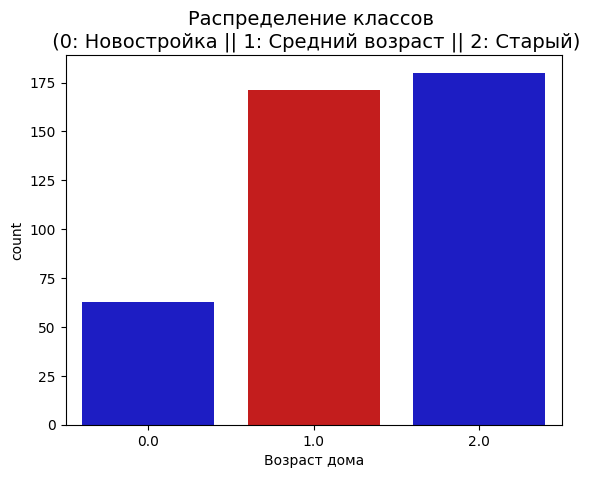

In [ ]:
colors = ["#0101DF", "#DF0101"]

sns.countplot(x='Возраст дома', data=df, palette=colors) # строим гистограмму целевой переменной
plt.title('Распределение классов \n (0: Новостройка || 1: Средний возраст || 2: Старый)', fontsize=14)


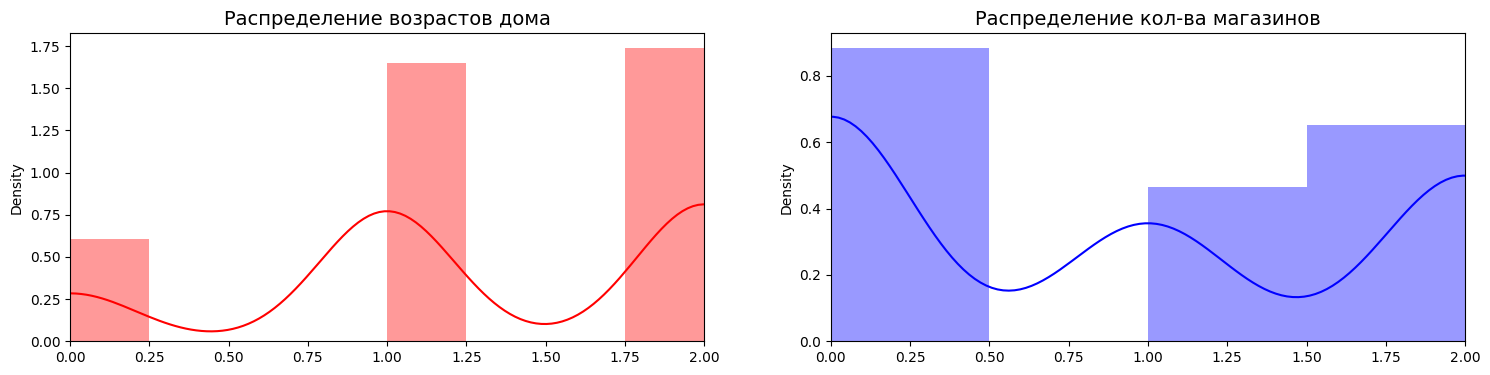

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(18,4))

age_val = df['Возраст дома'].values
mag_val = df['Кол-во магазинов'].values

# ВАШ КОД ЗДЕСЬ # строим график распределения возрастов дома
sns.distplot(age_val, ax=ax[0], color='r')
ax[0].set_title('Распределение возрастов дома', fontsize=14)
ax[0].set_xlim([min(age_val), max(age_val)])


# ВАШ КОД ЗДЕСЬ # строим график распределения кол-ва магазинов
sns.distplot(mag_val, ax=ax[1], color='b')
ax[1].set_title('Распределение кол-ва магазинов', fontsize=14)
ax[1].set_xlim([min(mag_val), max(mag_val)])

plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
import numpy as np
import pandas as pd

# 1. Разделяем признаки и целевую переменную
X = df.drop('Возраст дома', axis=1)
y = df['Возраст дома']

# 2. Делим на train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Выбираем столбцы для масштабирования (исключаем 'No', если он остался в X)
cols_to_scale = [col for col in X_train.columns if col != 'No']

rob_scaler = RobustScaler()

# 4. Масштабируем ТОЛЬКО признаки.
# ВАЖНО: fit_transform для train, transform для test (правило ML)
X_train[cols_to_scale] = rob_scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = rob_scaler.transform(X_test[cols_to_scale])

# 5. Преобразуем в numpy-массивы
original_Xtrain = X_train.values
original_Xtest = X_test.values
original_ytrain = y_train.values
original_ytest = y_test.values

# 6. Проверяем распределение классов
train_unique_label, train_counts_label = np.unique(original_ytrain, return_counts=True)
test_unique_label, test_counts_label = np.unique(original_ytest, return_counts=True)

print('Распределение классов: \n')
print("Обучающий набор:", train_counts_label / len(original_ytrain))
print("Тестовый набор:", test_counts_label / len(original_ytest))

Распределение классов: 

Обучающий набор: [0.16314199 0.41389728 0.42296073]
Тестовый набор: [0.10843373 0.40963855 0.48192771]


In [ ]:
# Поскольку наши классы сильно не сбалансированы, мы должны сделать их эквивалентными,
# чтобы получить нормальное распределение классов.

# Перемешаем данные перед созданием подвыборок

df = df.sample(frac=1)

fraud_df = df.loc[df['Возраст дома'] == 1]
non_fraud_df = df.loc[df['Возраст дома'] == 0][:492] # берем последние 492 транзакции

normal_distributed_df = pd.concat([fraud_df, non_fraud_df])

# Перемешивание строк датасета
new_df = normal_distributed_df.sample(frac=1, random_state=42)

new_df.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area,Возраст дома,Кол-во магазинов,Расстояние до ближайшей станции метро
179,180,2013.083333,14.0,438.8513,1,24.97493,121.52730,42.6,1.0,0.0,1.0
127,128,2013.250000,3.8,383.8624,5,24.98085,121.54391,55.0,0.0,2.0,1.0
353,354,2013.500000,4.1,2147.3760,3,24.96299,121.51284,31.3,0.0,0.0,1.0
61,62,2013.500000,5.3,259.6607,6,24.97585,121.54516,63.2,1.0,2.0,1.0
376,377,2013.416667,14.7,1717.1930,2,24.96447,121.51649,30.5,1.0,0.0,1.0


In [ ]:
new_df.shape

(234, 11)

Распределение классов в подвыборке
Возраст дома
1.0    0.730769
0.0    0.269231
Name: count, dtype: float64


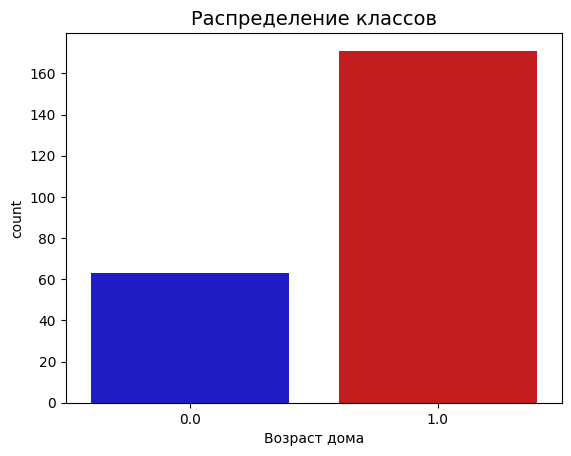

In [ ]:
print('Распределение классов в подвыборке')
print(new_df['Возраст дома'].value_counts()/len(new_df))

# проверяем снова распределение целевой переменной
sns.countplot(x='Возраст дома', data = new_df, palette = colors)
plt.title('Распределение классов', fontsize=14)
plt.show()

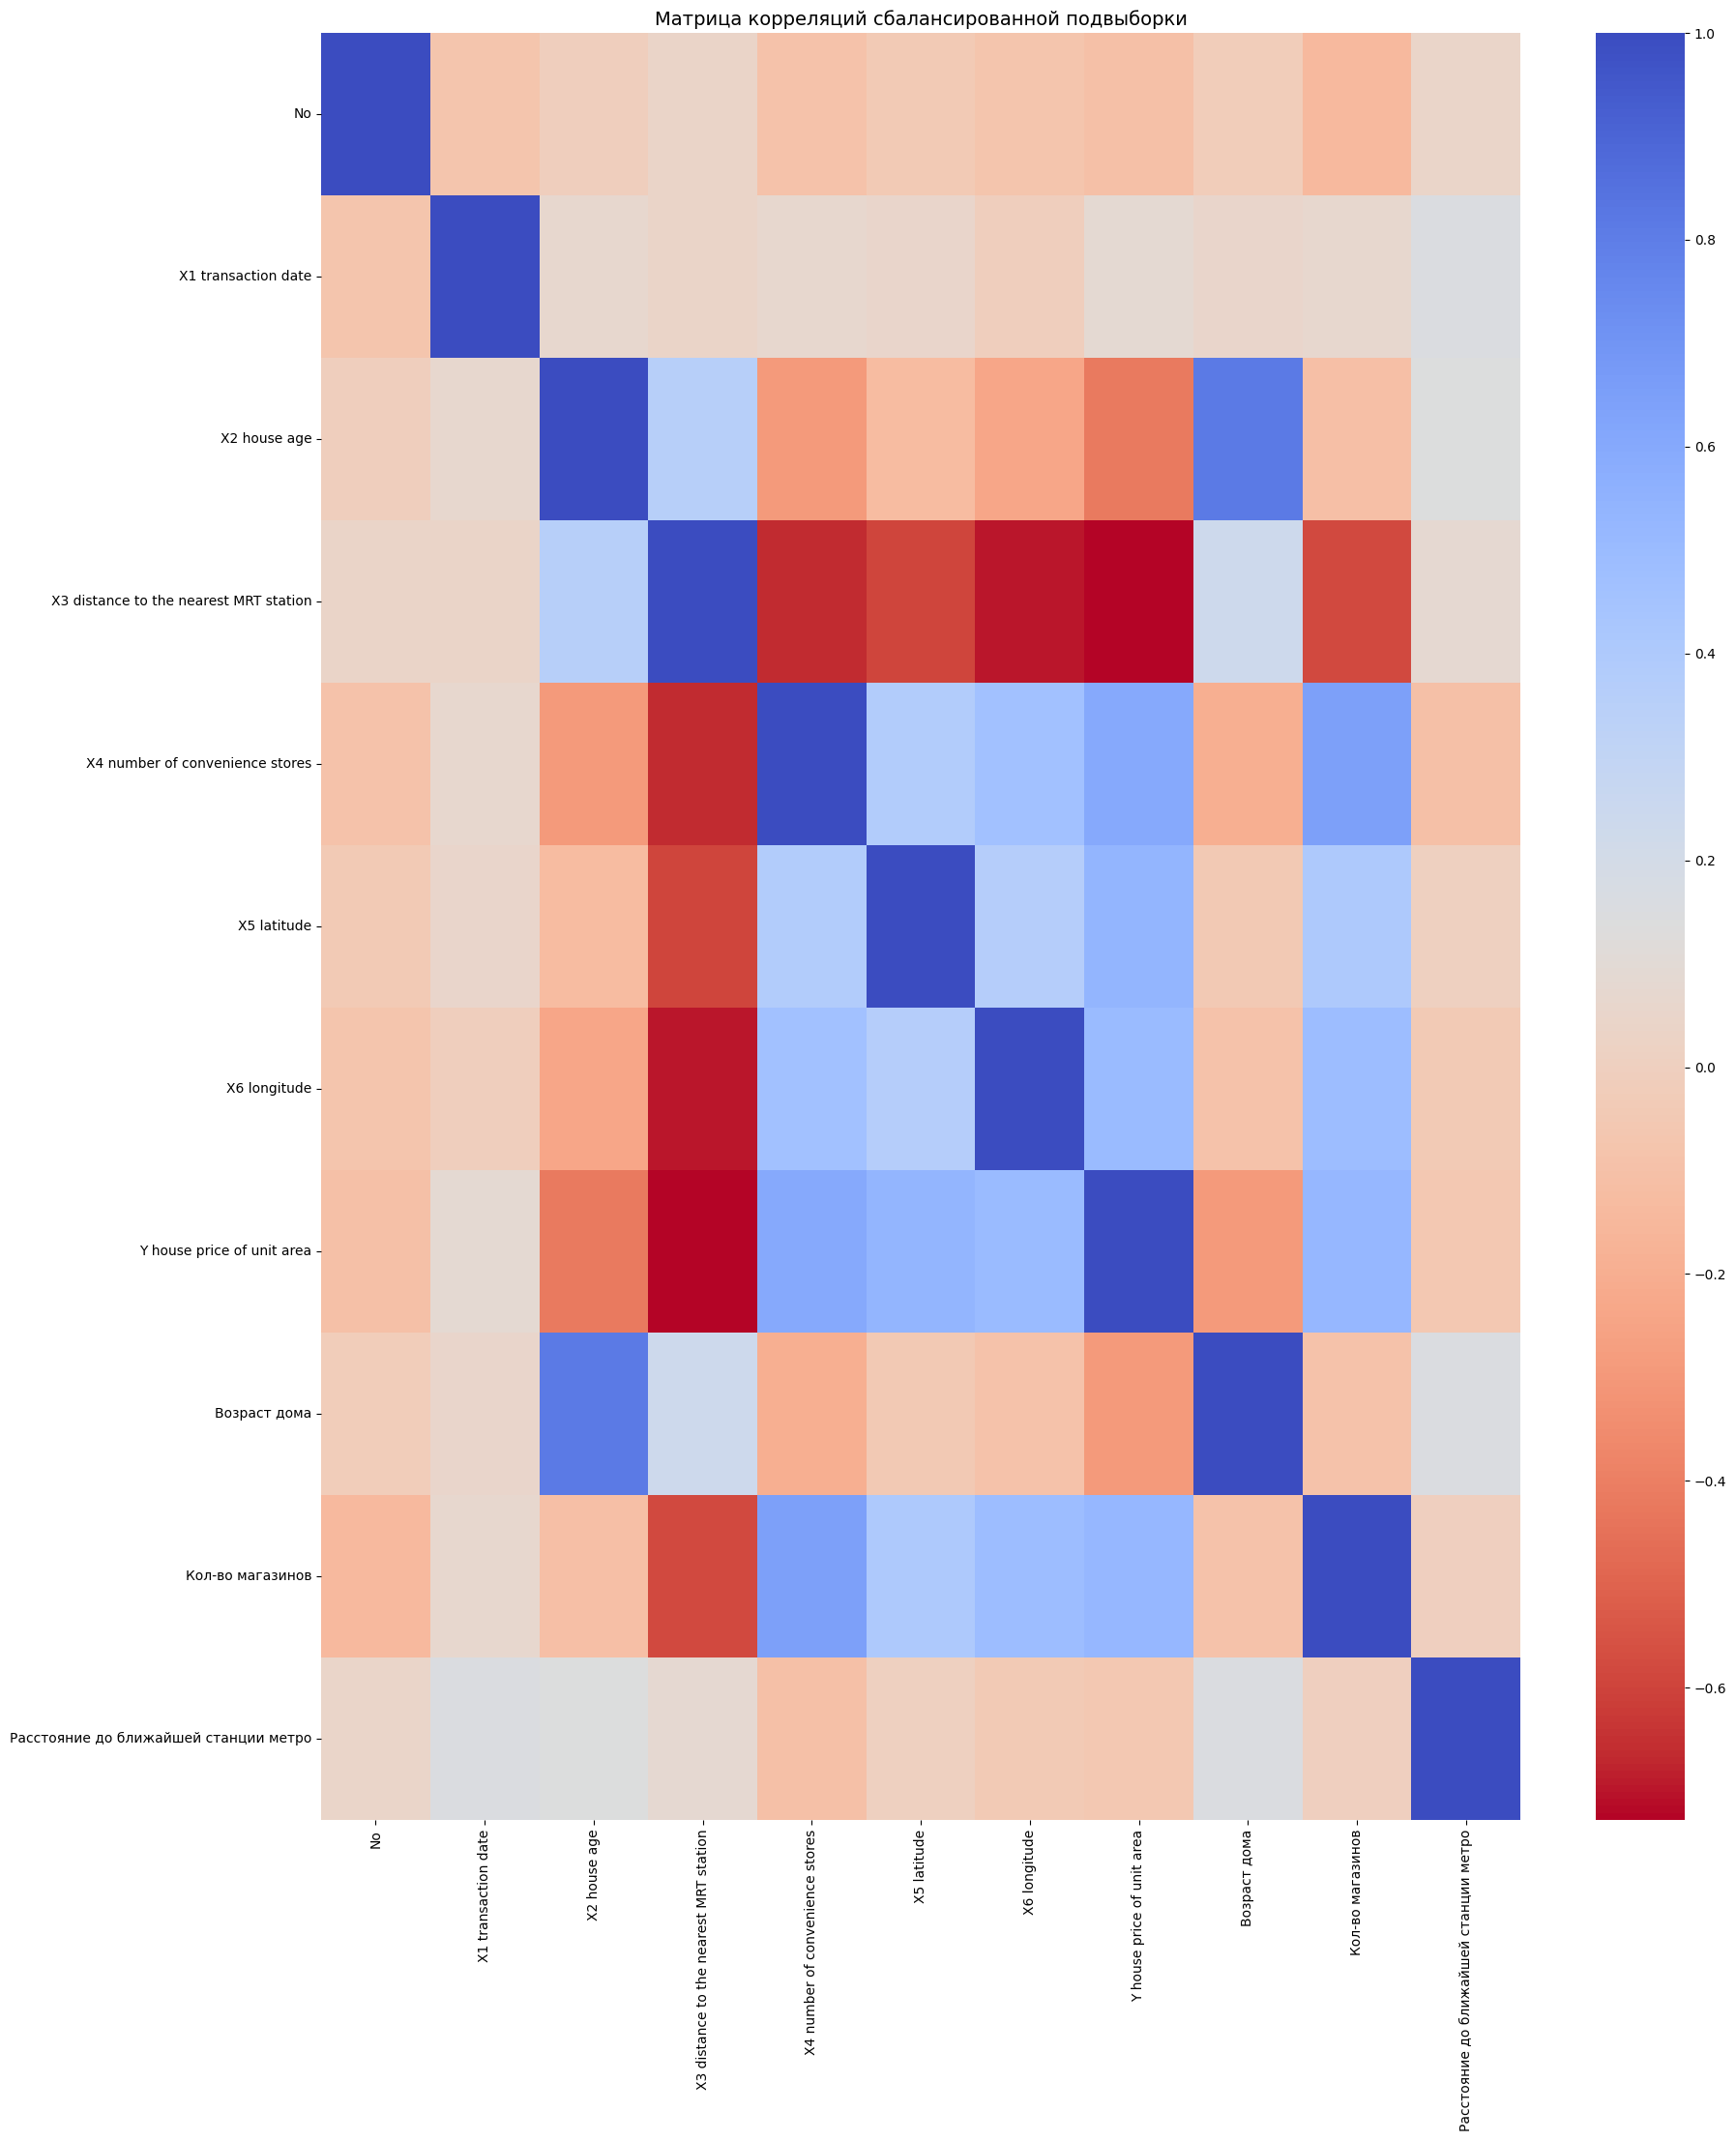

In [ ]:
f, ax = plt.subplots(1, 1, figsize=(20, 24))

# Построим матрицу корреляций

sub_sample_corr = new_df.corr()
sns.heatmap(sub_sample_corr, cmap = 'coolwarm_r', annot_kws ={'size':20}, ax=ax)
ax.set_title('Матрица корреляций сбалансированной подвыборки', fontsize=14)
plt.show()

### Выводы:
<ul>
<li><b>Отрицательные корреляции: </b>Признаки 'X4 number of convenience stores', 'X5 latitude', 'X6 longitude' имеют отрицательную корреляцию. Другими словами, чем ниже эти значения, тем больше вероятность того, что конечным результатом будет мошенническая операция.  </li>
<li> <b> Положительные корреляции: </b> Признаки 'X2 house age',
       'X3 distance to the nearest MRT station' положительно коррелируют. То есть, чем выше эти значения, тем больше вероятность того, что конечным результатом будет мошенническая операция. </li>
</ul>

Построим теперь Boxplot.

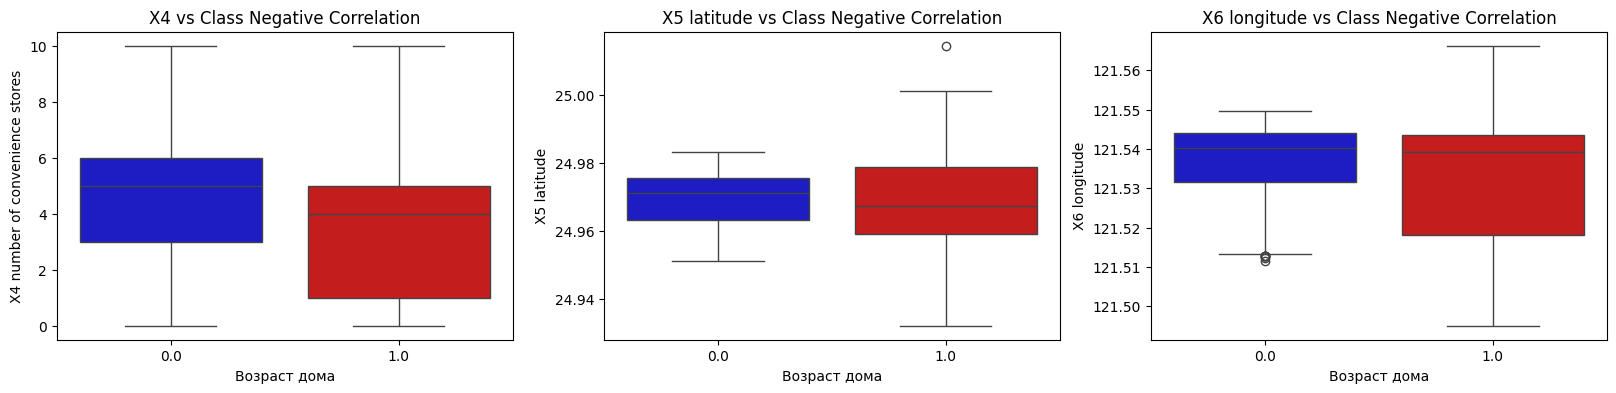

In [ ]:
f, axes = plt.subplots(ncols=3, figsize=(20,4))

#
sns.boxplot(x='Возраст дома', y='X4 number of convenience stores', data=new_df, palette=colors, ax=axes[0])
axes[0].set_title('X4 vs Class Negative Correlation')

#
sns.boxplot(x='Возраст дома', y='X5 latitude', data=new_df, palette=colors, ax=axes[1])
axes[1].set_title('X5 latitude vs Class Negative Correlation')


#
sns.boxplot(x='Возраст дома', y='X6 longitude', data=new_df, palette=colors, ax=axes[2])
axes[2].set_title('X6 longitude vs Class Negative Correlation')


plt.show()

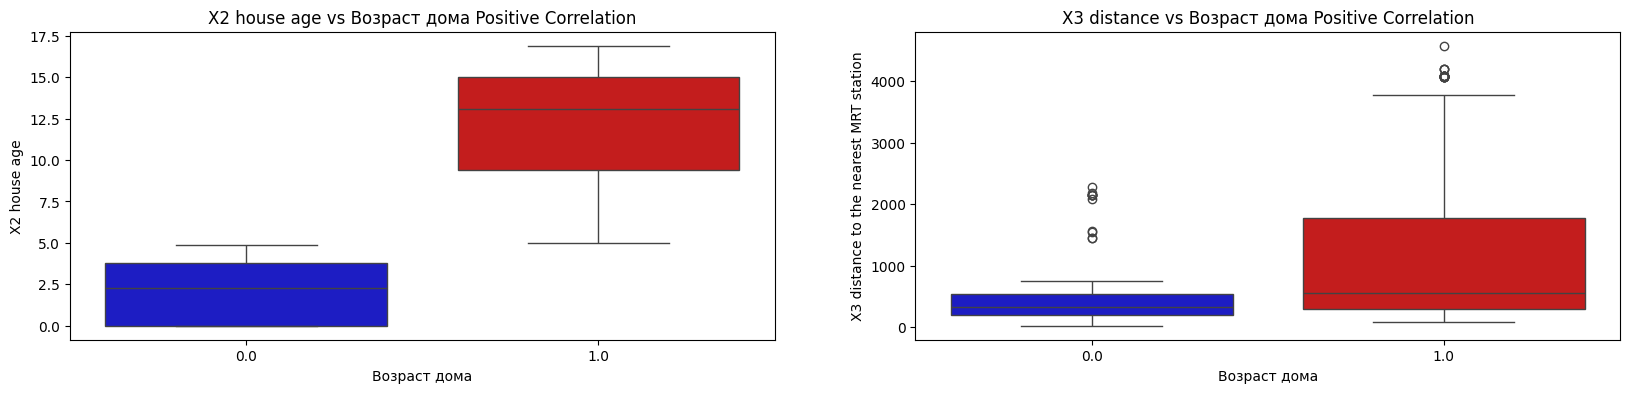

In [ ]:
f, axes = plt.subplots(ncols=2, figsize=(20,4))

#
sns.boxplot(x='Возраст дома', y='X2 house age', data=new_df, palette=colors, ax=axes[0])
axes[0].set_title('X2 house age vs Возраст дома Positive Correlation')

#
sns.boxplot(x='Возраст дома', y='X3 distance to the nearest MRT station', data=new_df, palette=colors, ax=axes[1])
axes[1].set_title('X3 distance vs Возраст дома Positive Correlation')


plt.show()

## Обработка выбросов

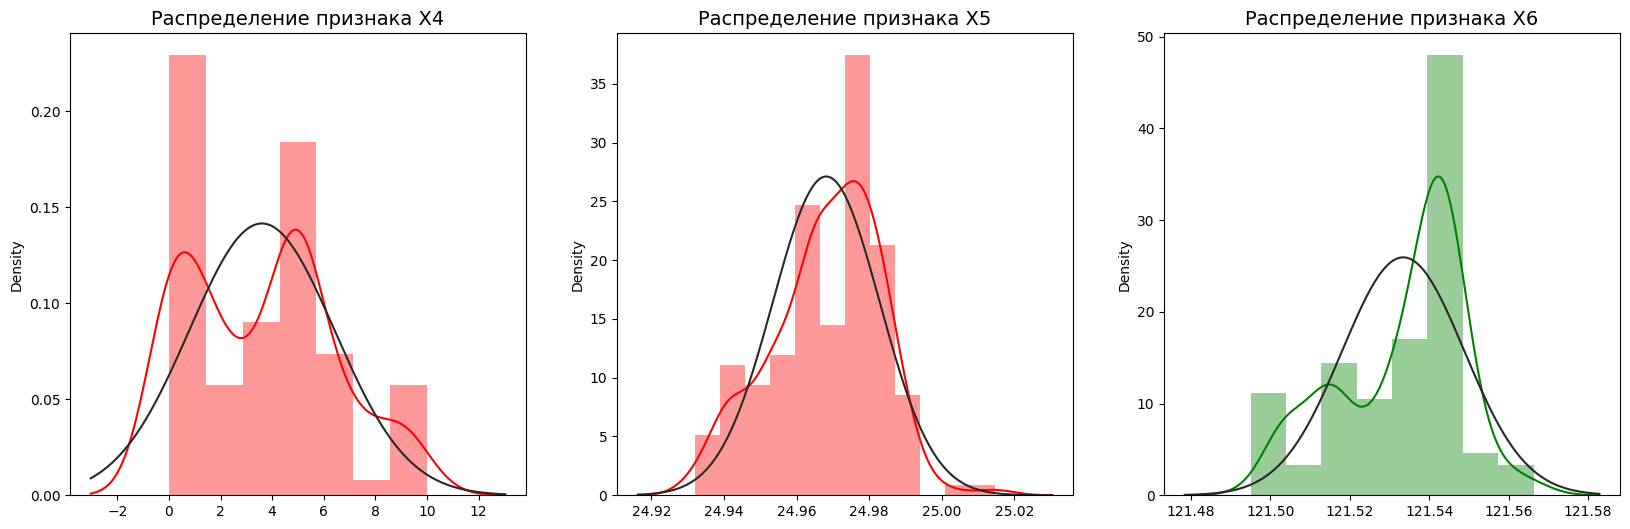

In [ ]:
# Строим распределения для V17, V14, V12, V10

from scipy.stats import norm

f, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(20, 6))

####
X4_fraud_dist = new_df['X4 number of convenience stores'].loc[new_df['Возраст дома'] == 1].values

sns.distplot(X4_fraud_dist, ax=ax1, fit=norm, color='r')
ax1.set_title('Распределение признака X4', fontsize=14)

####
X5_fraud_dist = new_df['X5 latitude'].loc[new_df['Возраст дома'] == 1].values

sns.distplot(X5_fraud_dist, ax=ax2, fit=norm, color='r')
ax2.set_title('Распределение признака X5', fontsize=14)

####
X6_fraud_dist = new_df['X6 longitude'].loc[new_df['Возраст дома'] == 1].values

sns.distplot(X6_fraud_dist, ax=ax3, fit=norm, color='g')
ax3.set_title('Распределение признака X6', fontsize=14)

plt.show()

In [ ]:
# Удаление выбросов из признака X4 number of convenience stores
X4_fraud = new_df['X4 number of convenience stores'].loc[new_df['Возраст дома'] == 1].values
q25, q75 = np.percentile(X4_fraud, 25), np.percentile(X4_fraud, 75)
print('Квартиль 25: {} | Квартиль 75: {}'.format(q25, q75))
X4_iqr = q75 - q25
print('iqr: {}'.format(X4_iqr))

X4_cut_off = X4_iqr * 1.5
X4_lower, X4_upper = q25 - X4_cut_off, q75 + X4_cut_off
print('Порог: {}'.format(X4_cut_off))
print('X4 нижняя граница: {}'.format(X4_lower))
print('X4 верхняя граница: {}'.format(X4_upper))

outliers = [x for x in X4_fraud if x < X4_lower or x > X4_upper]
print('Количество выбросов: {}'.format(len(outliers)))

new_df_without_outliers  = new_df.drop(new_df[(new_df['X4 number of convenience stores'] > X4_upper) | (new_df['X4 number of convenience stores'] < X4_lower)].index)
print('----' * 44)



####
# Удаление выбросов из признака X5 latitude
X5_fraud = new_df['X5 latitude'].loc[new_df['Возраст дома'] == 1].values
q25, q75 = np.percentile(X5_fraud, 25), np.percentile(X5_fraud, 75)
print('Квартиль 25: {} | Квартиль 75: {}'.format(q25, q75))
X5_iqr = q75 - q25
print('iqr: {}'.format(X5_iqr))

X5_cut_off = X5_iqr * 1.5
X5_lower, X5_upper = q25 - X5_cut_off, q75 + X5_cut_off
print('Порог: {}'.format(X5_cut_off))
print('X5 latitude нижняя граница: {}'.format(X5_lower))
print('X5 latitude верхняя граница: {}'.format(X5_upper))

outliers = [x for x in X5_fraud if x < X5_lower or x > X5_upper]
print('Количество выбросов: {}'.format(len(outliers)))

new_df_without_outliers  = new_df.drop(new_df[(new_df['X5 latitude'] > X5_upper) | (new_df['X5 latitude'] < X5_lower)].index)
print('----' * 44)



####
# Удаление выбросов из признака X6 longitude
X6_fraud = new_df['X6 longitude'].loc[new_df['Возраст дома'] == 1].values
q25, q75 = np.percentile(X6_fraud, 25), np.percentile(X6_fraud, 75)
print('Квартиль 25: {} | Квартиль 75: {}'.format(q25, q75))
X6_iqr = q75 - q25
print('iqr: {}'.format(X6_iqr))

X6_cut_off = X6_iqr * 1.5
X6_lower, X6_upper = q25 - X6_cut_off, q75 + X6_cut_off
print('Порог: {}'.format(X6_cut_off))
print('X6 longitude нижняя граница: {}'.format(X6_lower))
print('X6 longitude верхняя граница: {}'.format(X6_upper))
outliers = [x for x in X6_fraud if x < X6_lower or x > X6_upper]
print('Количество выбросов: {}'.format(len(outliers)))
new_df_without_outliers  = new_df_without_outliers.drop(new_df_without_outliers[(new_df_without_outliers['X6 longitude'] > X6_upper) | (new_df_without_outliers['X6 longitude'] < X6_lower)].index)
print('----' * 44)


Квартиль 25: 1.0 | Квартиль 75: 5.0
iqr: 4.0
Порог: 6.0
X4 нижняя граница: -5.0
X4 верхняя граница: 11.0
Количество выбросов: 0
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Квартиль 25: 24.95921 | Квартиль 75: 24.97886
iqr: 0.019650000000002166
Порог: 0.02947500000000325
X5 latitude нижняя граница: 24.929734999999994
X5 latitude верхняя граница: 25.008335000000002
Количество выбросов: 1
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Квартиль 25: 121.51813999999999 | Квартиль 75: 121.54348
iqr: 0.02534000000001413
Порог: 0.038010000000021194
X6 longitude нижняя граница: 121.48012999999997
X6 longitude верхняя граница: 121.58149000000003
Количество выбросов: 0
-----------------------------------------------------------------------

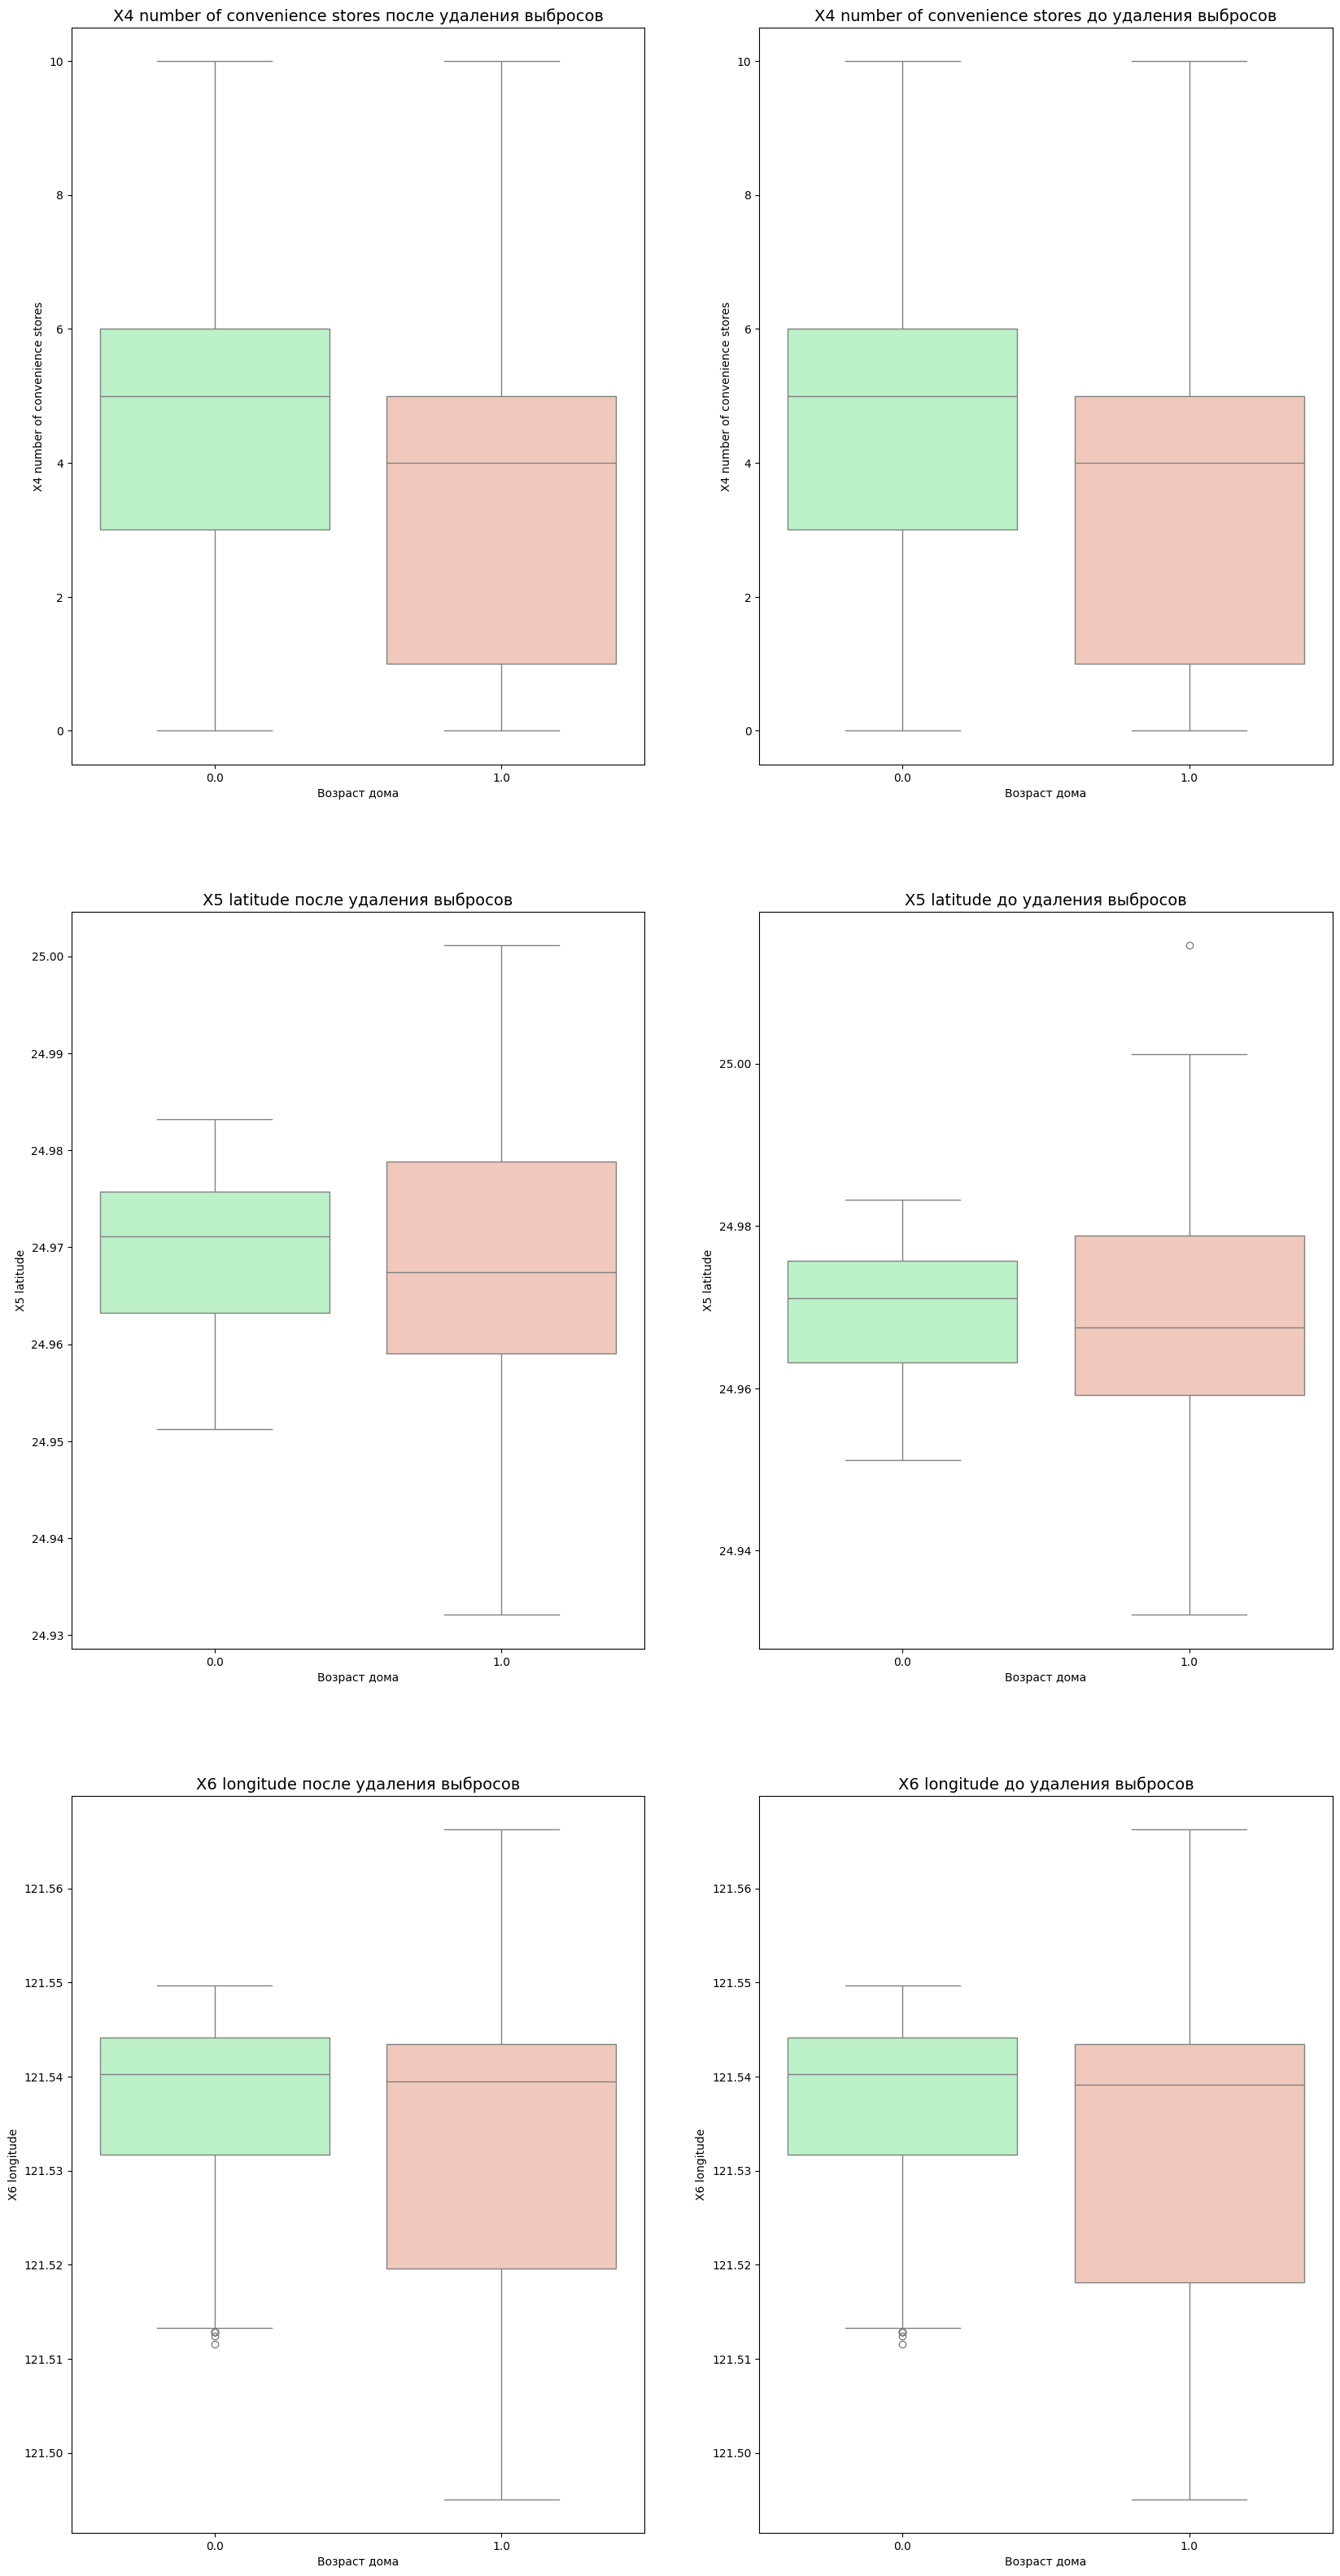

In [ ]:
f, ax = plt.subplots(3, 2, figsize=(20,40))

colors = ['#B3F9C5', '#f9c5b3']

# Boxplot для признака X4 number of convenience stores
sns.boxplot(x="Возраст дома", y="X4 number of convenience stores", data=new_df_without_outliers,ax=ax[0,0], palette=colors)
ax[0,0].set_title("X4 number of convenience stores после удаления выбросов", fontsize=14)
ax[0,0].annotate('Выбросы?', xy=(0.9, 0.1), xytext=(0, -12), fontsize=14)

# Boxplot для признака X4 number of convenience stores
sns.boxplot(x="Возраст дома", y="X4 number of convenience stores", data=new_df,ax=ax[0,1], palette=colors)
ax[0,1].set_title("X4 number of convenience stores до удаления выбросов", fontsize=14)
ax[0,1].annotate('Выбросы ?', xy=(0.98, -17.5), xytext=(0, -12), fontsize=14)

# Boxplot для признака X5 latitude
sns.boxplot(x="Возраст дома", y="X5 latitude", data=new_df_without_outliers,ax=ax[1,0], palette=colors)
ax[1,0].set_title("X5 latitude после удаления выбросов", fontsize=14)
ax[1,0].annotate('Выбросы?', xy=(0.9, 0.1), xytext=(0, -12), fontsize=14)

# Boxplot для признака X5 latitude
sns.boxplot(x="Возраст дома", y="X5 latitude", data=new_df,ax=ax[1,1], palette=colors)
ax[1,1].set_title("X5 latitude до удаления выбросов", fontsize=14)
ax[1,1].annotate('Выбросы', xy=(0.98, -17.5), xytext=(0, -12),
            arrowprops=dict(facecolor='black'), fontsize=14)

# Boxplot для признака X6 longitude
sns.boxplot(x="Возраст дома", y="X6 longitude", data=new_df_without_outliers, ax=ax[2,0], palette=colors)
ax[2,0].set_title("X6 longitude после удаления выбросов", fontsize=14)
ax[2,0].annotate('Выбросы?', xy=(0.9, 0.1), xytext=(0, -12), fontsize=14)


# Boxplot для признака X6 longitude
sns.boxplot(x="Возраст дома", y="X6 longitude", data=new_df, ax=ax[2,1], palette=colors)
ax[2,1].set_title("X6 longitude до удаления выбросов", fontsize=14)
ax[2,1].annotate('Выбросы', xy=(0.98, -17.3), xytext=(0, -12),
            arrowprops=dict(facecolor='black'), fontsize=14)


plt.show()

### Понижение размерности и кластеризация


In [ ]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA, TruncatedSVD

X = new_df.drop('Возраст дома', axis=1)
y = new_df['Возраст дома']

X.drop(['Кол-во магазинов','Расстояние до ближайшей станции метро'], axis=1, inplace=True) # Tак как Time и Amount не коррелируют почти с таргетом


# T-SNE алгоритм
t0 = time.time()
X_reduced_tsne = TSNE(n_components=2, random_state=42).fit_transform(X.values)
# ВАШ КОД ЗДЕСЬ
t1 = time.time()
print("T-SNE заняло {:.2} сек".format(t1 - t0))

# PCA алгоритм
t0 = time.time()
# ВАШ КОД ЗДЕСЬ
X_reduced_pca = PCA(n_components=2, random_state=42).fit_transform(X.values)
t1 = time.time()
print("PCA заняло {:.2} сек".format(t1 - t0))

# TruncatedSVD алгоритм
t0 = time.time()
# ВАШ КОД ЗДЕСЬ
X_reduced_svd = TruncatedSVD(n_components=2, algorithm='randomized', random_state=42).fit_transform(X.values)
t1 = time.time()
print("Truncated SVD заняло {:.2} сек".format(t1 - t0))

T-SNE заняло 4.9 сек
PCA заняло 0.022 сек
Truncated SVD заняло 0.014 сек


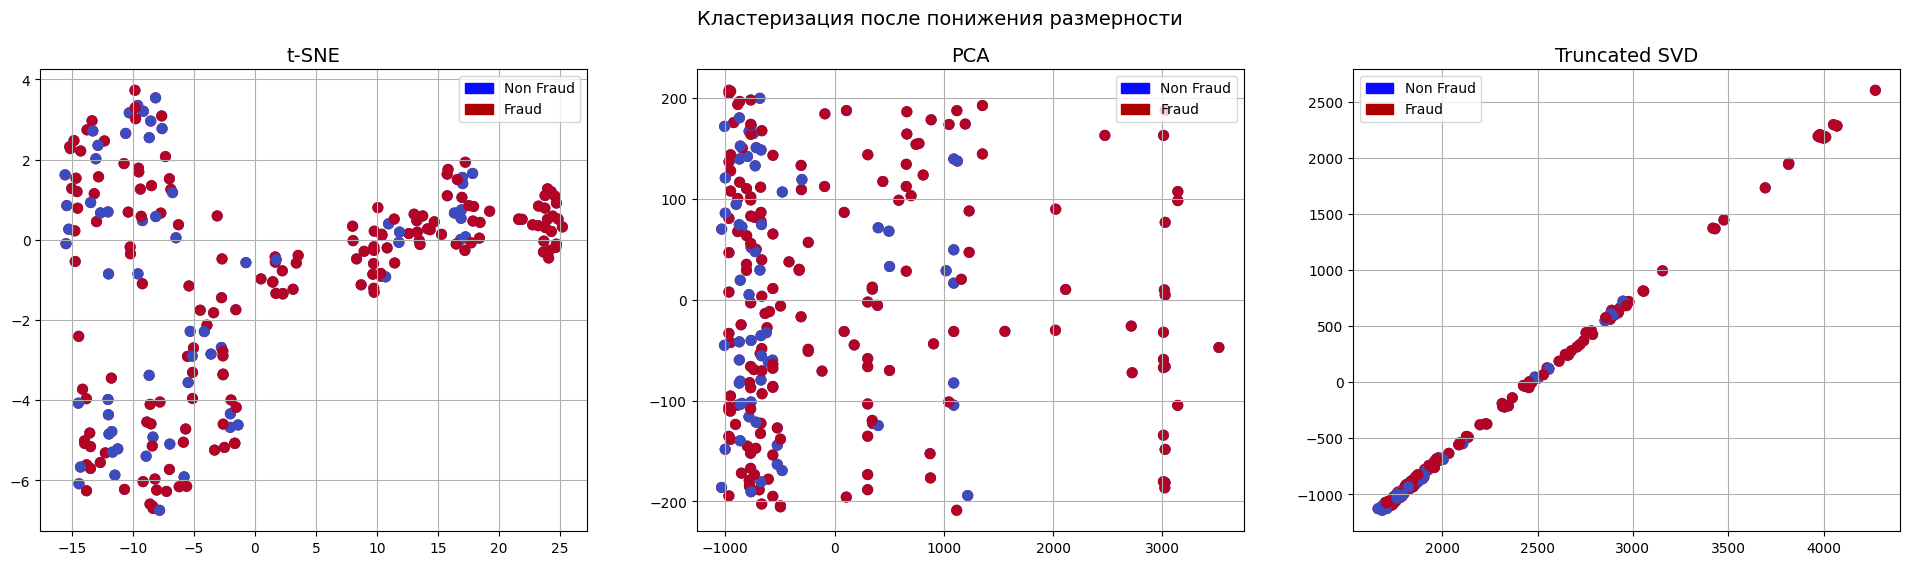

In [ ]:
f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24,6))
f.suptitle('Кластеризация после понижения размерности', fontsize=14)


blue_patch = mpatches.Patch(color='#0A0AFF', label='Non Fraud')
red_patch = mpatches.Patch(color='#AF0000', label='Fraud')


# t-SNE scatter plot
ax1.scatter(X_reduced_tsne[:,0], X_reduced_tsne[:,1], c=(y == 0), cmap='coolwarm', label='Non Fraud', linewidths=2)
ax1.scatter(X_reduced_tsne[:,0], X_reduced_tsne[:,1], c=(y == 1), cmap='coolwarm', label='Fraud', linewidths=2)
ax1.set_title('t-SNE', fontsize=14)

ax1.grid(True)

ax1.legend(handles=[blue_patch, red_patch])


# PCA scatter plot
ax2.scatter(X_reduced_pca[:,0], X_reduced_pca[:,1], c=(y == 0), cmap='coolwarm', label='Non Fraud', linewidths=2)
ax2.scatter(X_reduced_pca[:,0], X_reduced_pca[:,1], c=(y == 1), cmap='coolwarm', label='Fraud', linewidths=2)
ax2.set_title('PCA', fontsize=14)

ax2.grid(True)

ax2.legend(handles=[blue_patch, red_patch])

# TruncatedSVD scatter plot
ax3.scatter(X_reduced_svd[:,0], X_reduced_svd[:,1], c=(y == 0), cmap='coolwarm', label='Non Fraud', linewidths=2)
ax3.scatter(X_reduced_svd[:,0], X_reduced_svd[:,1], c=(y == 1), cmap='coolwarm', label='Fraud', linewidths=2)
ax3.set_title('Truncated SVD', fontsize=14)

ax3.grid(True)

ax3.legend(handles=[blue_patch, red_patch])

plt.show()